Phase 1 : Charger et explorer

Chargez un dataset de classification fourni par scikit-learn ( load_breast_cancer est un bon choix : 569
patients, 30 mesures, tumeur bénigne ou maligne). Inspectez-le avant toute chose.

In [1]:
from sklearn.datasets import load_breast_cancer
import numpy as np

In [11]:
def explorer_dataset():
    """Charge le dataset et affiche ses caractéristiques de base.
    Doit afficher : nombre de lignes, nombre de colonnes,
    les classes possibles et leur répartition (équilibrée ou non ?).
    """
    # TODO : charger le dataset (return_X_y=True donne X et y séparés)
    X, y = load_breast_cancer(return_X_y=True)
    # TODO : afficher la forme de X (combien de lignes, combien de colonnes)
    print(f"Lignes, colonnes : {X.shape}")
    # TODO : compter et afficher combien d'exemples dans chaque classe
    cas_malignes = (y == 0).sum()
    cas_benignes = (y == 1).sum()
    print(f"Classe 0 (maligne) : {cas_malignes} cas")
    print(f"Classe 1 (bénigne) : {cas_benignes} cas")
    pass

In [12]:
explorer_dataset()

Lignes, colonnes : (569, 30)
Classe 0 (maligne) : 212 cas
Classe 1 (bénigne) : 357 cas


Phase 2 : Le pipeline supervisé complet

Reprenez les 5 étapes du matin sur ce dataset : split, entraînement, prédiction, mesure. Encapsulez dans une
fonction qui prend un modèle en argument.

In [21]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [23]:
def entrainer_et_evaluer(modele, X_train, X_test, y_train, y_test):
    """Entraîne le modèle, prédit sur le test, renvoie l'accuracy.
    Doit renvoyer un float entre 0 et 1.
    """
    # TODO : entraîner le modèle sur les données d'apprentissage
    modele.fit(X_train, y_train)
    
    # TODO : prédire sur le jeu de test
    predictions = modele.predict(X_test)
    
    # TODO : calculer l'accuracy et la renvoyer
    score = accuracy_score(y_test, predictions)
    
    return score
    pass

In [25]:
# Charger les données 
X, y = load_breast_cancer(return_X_y=True)

# Séparer les données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# On crée notre modèle
mon_modele = DecisionTreeClassifier(random_state=42)

# On utilise ta nouvelle fonction
resultat = entrainer_et_evaluer(mon_modele, X_train, X_test, y_train, y_test)

print(f"Le score de précision (accuracy) est de : {resultat}")

Le score de précision (accuracy) est de : 0.9473684210526315


Phase 3 : L'Arène (premier classement)

Faites s'affronter au moins 3 algos sur le MÊME découpage train/test. Affichez un classement trié par accuracy.

In [26]:
from sklearn.neighbors import KNeighborsClassifier

In [59]:
def arene(X_train, X_test, y_train, y_test):
    """Entraîne plusieurs modèles, renvoie un classement trié.
    Doit afficher un tableau lisible : nom de l'algo, accuracy.
    """
    # TODO : construire un dictionnaire {nom: modèle} avec au moins 3 algos
    # (repensez à ceux du matin : arbre, régression logistique, KNN...)
    modeles = {
        "Arbre de décision": DecisionTreeClassifier(random_state=42),
        "KNN": KNeighborsClassifier(),
        "Régression logistique": LogisticRegression(max_iter=10000)
    }
    # TODO : pour chaque modèle, réutiliser entrainer_et_evaluer sur le MÊME split
    results = []
    for nom, modele in modeles.items():
        accuracy = entrainer_et_evaluer(modele, X_train, X_test, y_train, y_test)
        results.append((nom, accuracy))

    results.sort(reverse=True)

    # TODO : trier par accuracy décroissante et afficher le podium
    print("Classement des modèles :")
    for nom, accuracy in results:
        resultat_percent = accuracy * 100
        print(f"{nom} : {resultat_percent:.1f}%")

    pass


In [60]:
arene(X_train, X_test, y_train, y_test)

Classement des modèles :
Régression logistique : 95.6%
KNN : 95.6%
Arbre de décision : 94.7%


Si on ne met pas `max_iter=10000`, la Régression Logistique affiche une erreur

**Pourquoi ?**
La régression logistique n'a pas réussi à converger en 100 étapes, car les variables ont des échelles très différentes, ce qui ralentit son apprentissage.

**Que se passe-t-il si on augmente max_iter ?**
En augmentant max_iter à 10000, on donne plus de temps à l'algorithme pour trouver la solution.

Phase 4 : Bascule non-supervisé

Maintenant, cachez les étiquettes. Lancez un KMeans qui doit trouver 2 groupes tout seul, sans jamais voir y .
Puis comparez : les groupes trouvés correspondent-ils aux vraies classes (bénigne/maligne) ?

In [35]:
from sklearn.cluster import KMeans

In [40]:
def clustering_aveugle(X):
    """Regroupe les données en 2 clusters sans les étiquettes.
    Renvoie les labels de cluster attribués à chaque point.
    """
    # TODO : créer un KMeans à 2 clusters et renvoyer le cluster de chaque point
    # (indice : une seule méthode fait l'entraînement ET la prédiction d'un coup)
    kmeans = KMeans(n_clusters=2, random_state=42)
    clusters = kmeans.fit_predict(X)
    return clusters
    pass

In [ ]:
# On lance notre fonction sur tout le dataset X
labels_kmeans = clustering_aveugle(X)

# On calcule le nombre total de patients
total_patients = len(y)

# KMeans a utilisé la même logique que nous (0 = maligne, 1 = bénigne)
match_direct = (labels_kmeans == y).sum()

# On garde le meilleur des deux scores
pourcentage_reussite = (match_direct / total_patients) * 100

print(f"L'algorithme aveugle a retrouvé les bonnes classes à {pourcentage_reussite:.1f}% !")

L'algorithme aveugle a retrouvé les bonnes classes à 85.4% !


Le clustering a bien réussi (≈85%). Ce n’est pas de la chance, les données contiennent une vraie structure. Les tumeurs bénignes et malignes ont des caractéristiques différentes, et KMeans a réussi à les regrouper correctement.

Phase 5 : Changer de terrain

Reprenez toute votre Arène, mais sur un autre dataset. load_wine est parfait : 3 classes au lieu de 2 (donc de la classification multi-classe), 13 mesures. Relancez l'exploration puis le classement, sans réécrire vos fonctions.

In [48]:
from sklearn.datasets import load_wine

In [50]:
X_wine, y_wine = load_wine(return_X_y=True)
y_wine_liste = list(y_wine)

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_wine, y_wine, test_size=0.2, random_state=42)
arene(X_train_w, X_test_w, y_train_w, y_test_w)

Classement des modèles :
Régression logistique : 100.0%
KNN : 72.2%
Arbre de décision : 94.4%


In [ ]:
Le meilleur modèle peut changer selon les données, il n’existe pas d’algorithme toujours supérieur.

Les modèles scikit-learn fonctionnent aussi avec plusieurs classes sans changement, ils s’adaptent automatiquement.

Si une classe est moins représentée, le modèle peut mieux apprendre les classes majoritaires et se tromper plus souvent sur la minorité.

Phase 6 : Voir pour comprendre

Un classement de chiffres, c'est bien. Un graphique, c'est mieux pour décider. Avec matplotlib, tracez un diagramme en barres des accuracies de vos algos. Puis, pour votre champion, affichez sa matrice de confusion : le tableau qui montre non seulement combien d'erreurs il fait, mais lesquelles (quelles classes il confond).

In [52]:
import matplotlib.pyplot as plt

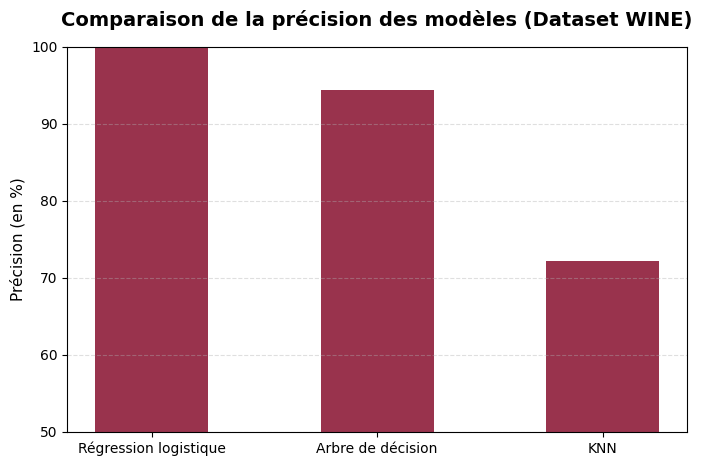

In [62]:
noms_modeles = ["Régression logistique", "Arbre de décision", "KNN"]
scores_wine = [100.0, 94.4, 72.2] 

plt.figure(figsize=(8, 5))

plt.bar(noms_modeles, scores_wine, color='#800020', alpha=0.8, width=0.5)

plt.title("Comparaison de la précision des modèles (Dataset WINE)", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Précision (en %)", fontsize=11)

plt.ylim(50, 100) 

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

La matrice compare 3 cépages : la diagonale montre les bonnes prédictions.
Les erreurs montrent quelles classes sont souvent confondues entre elles.
Ici, les erreurs ne sont pas critiques pour la vie, mais peuvent poser des problèmes de qualité ou d’étiquetage du vin.

Phase 7 : Le buff scaling (et la triche qui se retourne contre vous)

Souvenez-vous de l'avertissement de la régression logistique en Phase 3. Certains algos sont aveugles aux échelles, d'autres en souffrent énormément. On va le prouver chiffres en main, puis tomber exprès dans un piège que presque tout le monde se prend une fois dans sa carrière.
Manche 1 : le buff. Mettez vos données à l'échelle avec un StandardScaler (il ramène chaque colonne sur une moyenne de 0 et un écart-type de 1, donc une échelle comparable), et relancez l'Arène complète. Pour chaque algo, mesurez le gain : accuracy scalée moins accuracy brute.


In [63]:
from sklearn.preprocessing import StandardScaler

In [70]:
def comparer_scaling(modeles, X_train, X_test, y_train, y_test):
    """
    Pour chaque algo, mesure l'accuracy SANS puis AVEC scaling.
    Affiche un tableau trié par gain décroissant.
    """
    resultats = []
    
    for nom, modele in modeles.items():
        # TODO : pour chaque modèle, évaluer une première fois sur les données brutes
        score_brut = entrainer_et_evaluer(modele, X_train, X_test, y_train, y_test)
        
        # TODO : ajuster un StandardScaler sur le TRAIN seul, transformer train ET test
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test) # On utilise juste .transform() ici
        
        # TODO : ré-évaluer le même modèle sur les données scalées
        score_scale = entrainer_et_evaluer(modele, X_train_scaled, X_test_scaled, y_train, y_test)
        
        # TODO : calculer le delta (scalé - brut), trier par delta décroissant, afficher
        delta = score_scale - score_brut
        
        resultats.append((delta, nom, score_brut, score_scale))
        
    resultats.sort(reverse=True)
    
    print(f"{'Algo'} | {'Brut'} | {'Scalé'} | {'Gain'}")
    print("-" * 55)
    for delta, nom, brut, scale in resultats:
        print(f"{nom} | {brut*100:5.1f}% | {scale*100:5.1f}% | {delta*100:+4.1f}")

In [71]:
modeles_arene = {
    "KNN": KNeighborsClassifier(),
    "Régression logistique": LogisticRegression(max_iter=10000, random_state=42),
    "Arbre de décision": DecisionTreeClassifier(random_state=42)
}

comparer_scaling(modeles_arene, X_train_w, X_test_w, y_train_w, y_test_w)

Algo | Brut | Scalé | Gain
-------------------------------------------------------
KNN |  72.2% |  94.4% | +22.2
Régression logistique | 100.0% | 100.0% | +0.0
Arbre de décision |  94.4% |  94.4% | +0.0


KNN gagne beaucoup avec le scaling, car les distances deviennent justes entre les variables.La régression logistique est un peu plus stable et efficace avec des données scalées.
L’arbre de décision ne change pas, car il ne dépend pas des distances ni des échelles.

Manche 2 : la triche. Maintenant on triche volontairement. Ajustez votre scaler sur le dataset COMPLET ( fit
sur tout X, AVANT le split), puis splittez et relancez votre champion. Notez sa nouvelle accuracy

In [76]:
scaler_tricheur = StandardScaler()
X_wine_triche = scaler_tricheur.fit_transform(X_wine) 

X_train_triche, X_test_triche, y_train_triche, y_test_triche = train_test_split(
    X_wine_triche, y_wine, test_size=0.2, random_state=42
)

champion = LogisticRegression(max_iter=10000, random_state=42)

scaler_honnete = StandardScaler()
X_train_honnete = scaler_honnete.fit_transform(X_train_w)
X_test_honnete = scaler_honnete.transform(X_test_w)

score_honnete = entrainer_et_evaluer(champion, X_train_honnete, X_test_honnete, y_train_w, y_test_w)

score_tricheur = entrainer_et_evaluer(champion, X_train_triche, X_test_triche, y_train_triche, y_test_triche)

mensonge = score_tricheur - score_honnete

print(f"Score honnête (réel) : {score_honnete * 100:.2f}%")
print(f"Score tricheur (fuite): {score_tricheur * 100:.2f}%")
print(f"Le Mensonge (Delta)  : {mensonge * 100:+.2f} points")

Score honnête (réel) : 100.00%
Score tricheur (fuite): 100.00%
Le Mensonge (Delta)  : +0.00 points


Comparer les deux scores montre si on a “triché” en utilisant toutes les données pour scaler. Ici, le score est identique (100% vs 100%), donc aucun gain.